In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('test_dataset_anonymized.xlsx')
df.head()  # view first 5 rows

,user_id,is_trial,first_event_date,subscription_renewal_amount,Unnamed: 4,Subs type,Trial period,Subscription period,First payment,Rebill payment
0,21889,1,2022-01-01,0,NaN,trial,7 days,1 month,6.99,29.99
1,21890,1,2019-07-01,0,NaN,wo trial,No trial,3 months,40.00,40.00
2,21891,1,2019-07-01,0,NaN,Subscription is renewed automatically\t\t\t,NaN,NaN,NaN,NaN
3,21892,1,2019-07-01,0,NaN,NaN,NaN,NaN,NaN,NaN
4,21894,1,2019-07-01,0,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
# Let's keep only the columns we need to work with:
df = df[['user_id','is_trial','first_event_date','subscription_renewal_amount']]

# Check the data types:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   user_id                      9426 non-null   int64         
 1   is_trial                     9426 non-null   int64         
 2   first_event_date             9426 non-null   datetime64[us]
 3   subscription_renewal_amount  9426 non-null   int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 294.7 KB


In [85]:
# check dataframe size:
df.shape

# explore basic stats:
df.describe()


,user_id,is_trial,first_event_date,subscription_renewal_amount
count,9426.000000,9426.000000,9426,9426.000000
mean,23609.311161,0.338320,2019-07-05 04:05:57.479312,5.569489
min,21889.000000,0.000000,2019-07-01 00:00:00,0.000000
25%,22736.000000,0.000000,2019-07-03 00:00:00,0.000000
50%,23572.000000,0.000000,2019-07-06 00:00:00,2.000000
75%,24428.000000,1.000000,2019-07-07 00:00:00,9.000000
max,115217.000000,1.000000,2022-01-01 00:00:00,26.000000
std,1779.225697,0.473163,NaN,6.964244


1: Finding total revenue for trial users: 


In [86]:
# filter trial users
trial_df = df[df['is_trial'] == 0]
trial_df.head()

# calculate revenue per user
trial_df['revenue'] = 6.99 + trial_df['subscription_renewal_amount'] * 29.99

# total revenue
total_revenue_trial = trial_df['revenue'].sum()

print(f'Total revenue for trial users: ${total_revenue_trial:,.2f}')

Total revenue for trial users: $1,617,981.66


2a: Segmenting users by number of renewals:

In [87]:
# Number of users by renewal count:
renewals_by_users = df.groupby('subscription_renewal_amount')['user_id'].count().reset_index().rename(columns={'user_id': 'number_of_users',
                                                                                                    'subscription_renewal_amount': 'number_of_renewals'})

print(renewals_by_users)

    number_of_renewals  number_of_users
0                    0             3188
1                    1              982
2                    2              633
3                    3              498
4                    4              411
5                    5              353
6                    6              321
7                    7              281
8                    8              252
9                    9              236
10                  10              228
11                  11              206
12                  12              190
13                  13              174
14                  14              163
15                  15              147
16                  16              139
17                  17              134
18                  18              126
19                  19              117
20                  20              108
21                  21              102
22                  22               96
23                  23               92


2b: Total Revenue by segments (for Trial only): 

In [88]:
revenue_by_renewals = trial_df.groupby('subscription_renewal_amount')['revenue'].sum().reset_index().rename(columns={'subscription_renewal_amount': 'number_of_renewals', 'revenue': 'revenue_by_renewals'}).sort_values('number_of_renewals')

print(revenue_by_renewals)

    number_of_renewals  revenue_by_renewals
0                    1             36277.38
1                    2             42392.01
2                    3             48286.08
3                    4             52176.45
4                    5             55399.82
5                    6             60004.53
6                    7             60954.52
7                    8             62221.32
8                    9             65348.40
9                   10             69970.92
10                  11             69397.28
11                  12             69705.30
12                  13             69053.64
13                  14             69576.55
14                  15             67155.48
15                  16             67669.37
16                  17             69253.88
17                  18             68898.06
18                  19             67485.60
19                  20             65533.32
20                  21             64951.56
21                  22          

3: Average LTV by subscription types

In [89]:
# Calculate LTV per user for both subscription types
df['ltv'] = np.where(
    df['is_trial'] == 0,
    6.99 + df['subscription_renewal_amount'] * 29.99,
    40.00 + df['subscription_renewal_amount'] * 40.00
)

# Average LTV by subsription type
ltv_by_type = df.groupby('is_trial')['ltv'].agg(['mean', 'median']).reset_index().rename(columns={'ltv': 'avg_ltv'})

print(ltv_by_type)

   is_trial        mean  median
0         0  259.416652  186.93
1         1   40.012543   40.00


4: Quarterly revenue

In [90]:
# Create payment timeline for each user
df['number_of_renewals'] = df['subscription_renewal_amount'].apply(
    lambda x: list(range(0, x + 1))
) 

# With 'explode' - unpack each user row into one row per payment
payments_df = df.explode('number_of_renewals').reset_index(drop=True)

payments_df.head(10)

,user_id,is_trial,first_event_date,subscription_renewal_amount,ltv,number_of_renewals
0,21889,1,2022-01-01,0,40.0,0
1,21890,1,2019-07-01,0,40.0,0
2,21891,1,2019-07-01,0,40.0,0
3,21892,1,2019-07-01,0,40.0,0
4,21894,1,2019-07-01,0,40.0,0
5,21895,1,2019-07-01,0,40.0,0
6,21896,1,2019-07-01,0,40.0,0
7,21897,1,2019-07-01,0,40.0,0
8,21898,1,2019-07-01,0,40.0,0
9,21899,1,2019-07-01,0,40.0,0


In [91]:
# Calculate payment date for each renewal
payments_df['payment_date'] = np.where(
    payments_df['is_trial'] == 0,
    payments_df['first_event_date'] + pd.to_timedelta(7 + payments_df['number_of_renewals'] * 30, unit='D'),
    payments_df['first_event_date'] + pd.to_timedelta(payments_df['number_of_renewals'] * 90, unit='D')
)

# Calculate payment amount for each renewal
payments_df['payment_amount'] = np.where(
    payments_df['is_trial'] == 0,
    np.where(payments_df['number_of_renewals'] == 0, 6.99, 29.99),
    40.00
)

payments_df.head(100)

,user_id,is_trial,first_event_date,subscription_renewal_amount,ltv,number_of_renewals,payment_date,payment_amount
0,21889,1,2022-01-01,0,40.0,0,2022-01-01,40.0
1,21890,1,2019-07-01,0,40.0,0,2019-07-01,40.0
2,21891,1,2019-07-01,0,40.0,0,2019-07-01,40.0
3,21892,1,2019-07-01,0,40.0,0,2019-07-01,40.0
4,21894,1,2019-07-01,0,40.0,0,2019-07-01,40.0
...,...,...,...,...,...,...,...,...
95,21992,1,2019-07-01,0,40.0,0,2019-07-01,40.0
96,21993,1,2019-07-01,0,40.0,0,2019-07-01,40.0
97,21994,1,2019-07-01,0,40.0,0,2019-07-01,40.0
98,21995,1,2019-07-01,0,40.0,0,2019-07-01,40.0


In [92]:
# Self-check that 'explode' worked out correctly
print(payments_df.shape)
print(payments_df['number_of_renewals'].unique())

(61924, 8)
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]


In [93]:
# Extract quarter from payment date
payments_df['quarter'] = payments_df['payment_date'].dt.to_period('Q')

# Group by quarter and sum revenue
quarterly_revenue = payments_df.groupby('quarter')['payment_amount'].sum().reset_index().rename(columns={'payment_amount': 'total_revenue'}).sort_values('quarter')

print(quarterly_revenue)

  quarter  total_revenue
0  2019Q3      515791.70
1  2019Q4      373775.38
2  2020Q1      274708.40
3  2020Q2      204561.79
4  2020Q3      151029.64
5  2020Q4      109793.39
6  2021Q1       66307.89
7  2021Q2       37157.61
8  2021Q3       12415.86
9  2022Q1          40.00


5: Cohort analysis

In [94]:
# Derfine cohort by quarter of first_event_date
payments_df['cohort'] = payments_df['first_event_date'].dt.to_period('Q')

# Calculate number of months elapsed from first payment to each subsequent payment
payments_df['periods_since_start'] = (
    payments_df['payment_date'].dt.to_period('M').astype(int) - 
    payments_df['first_event_date'].dt.to_period('M').astype(int)
)

# Group by cohort and periods
cohort_revenue = payments_df.groupby(['cohort', 'periods_since_start'])['payment_amount'].sum().reset_index().rename(columns={'payment_amount': 'total_revenue'}).sort_values(['cohort','periods_since_start'])

cohort_revenue.head(30)

,cohort,periods_since_start,total_revenue
0,2019Q3,0,171116.63
1,2019Q3,1,187047.63
2,2019Q3,2,157627.44
3,2019Q3,3,138683.77
4,2019Q3,4,123708.75
5,2019Q3,5,111382.86
6,2019Q3,6,100796.39
7,2019Q3,7,91169.60
8,2019Q3,8,82742.41
9,2019Q3,9,75184.93


Adding Visualisations:

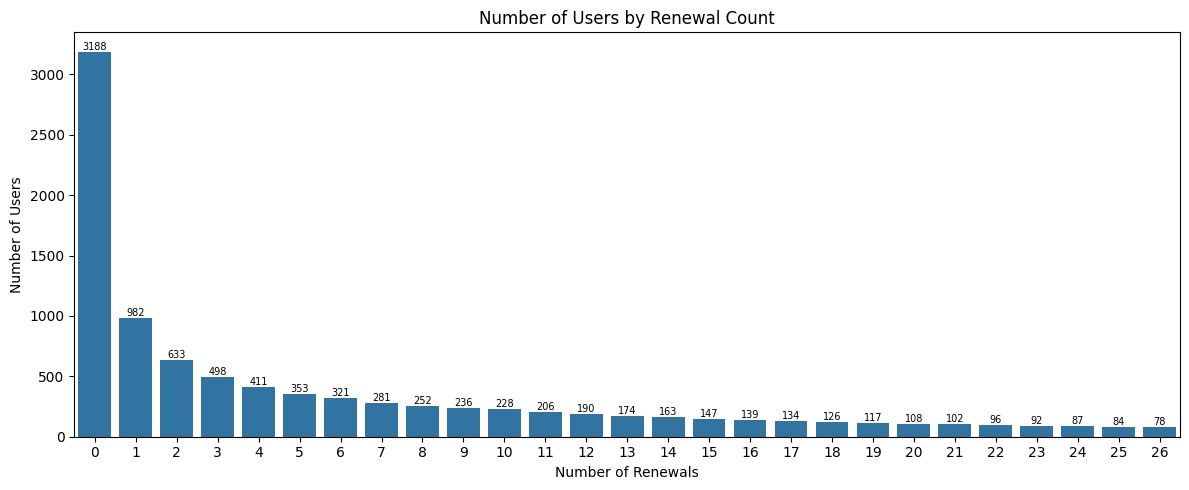

In [95]:
# Number of Users by Renewal Count
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data= renewals_by_users,
    x='number_of_renewals',
    y='number_of_users'
)
# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7)

plt.title('Number of Users by Renewal Count')
plt.xlabel('Number of Renewals')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

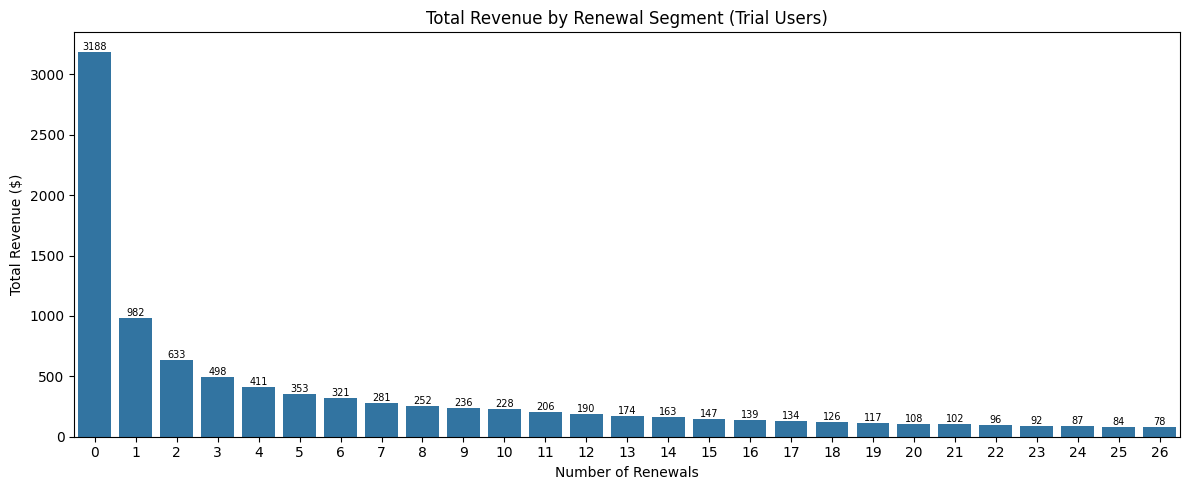

In [96]:
# Total Revenue by Renewal Segment (Trial Users)
plt.figure(figsize=(12, 5))


ax = sns.barplot(
    data=renewals_by_users,
    x='number_of_renewals',
    y='number_of_users'
)
# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7)

plt.title('Total Revenue by Renewal Segment (Trial Users)')
plt.xlabel('Number of Renewals')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

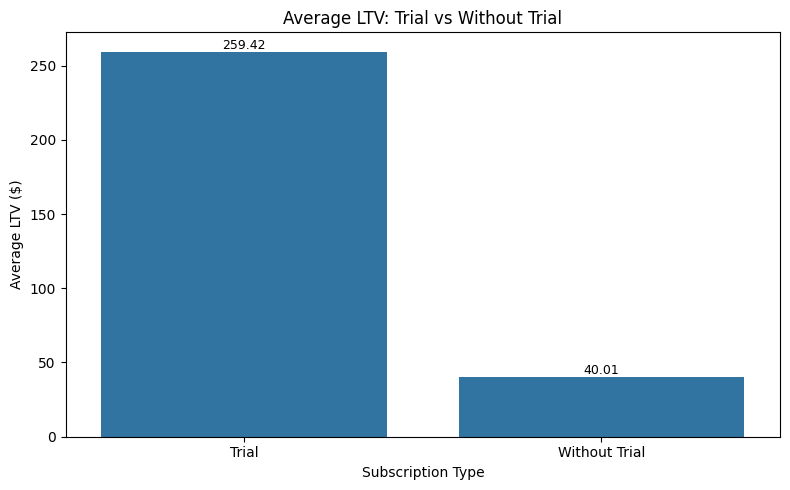

In [97]:
# AVG LTV (Trial vs Non-Trial)
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=ltv_by_type,
    x='is_trial',
    y='mean'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.title('Average LTV: Trial vs Without Trial')
plt.xlabel('Subscription Type')
plt.ylabel('Average LTV ($)')
plt.xticks([0, 1], ['Trial', 'Without Trial'])
plt.tight_layout()
plt.show()

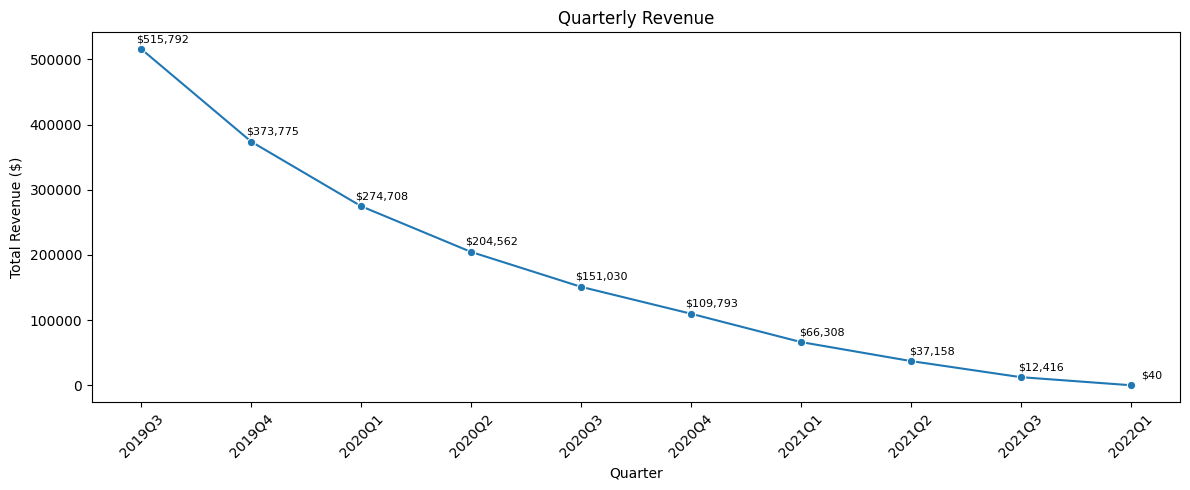

In [106]:
# Quarterly Revenue
quarterly_revenue['quarter'] = quarterly_revenue['quarter'].astype(str)
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=quarterly_revenue,
    x='quarter',
    y='total_revenue',
    marker='o'
)

for x, y in zip(quarterly_revenue['quarter'], quarterly_revenue['total_revenue']):
    plt.annotate(f'${y:,.0f}', 
                xy=(x, y),
                xytext=(15, 5),
                textcoords='offset points',
                ha='center',
                fontsize=8)

plt.title('Quarterly Revenue')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

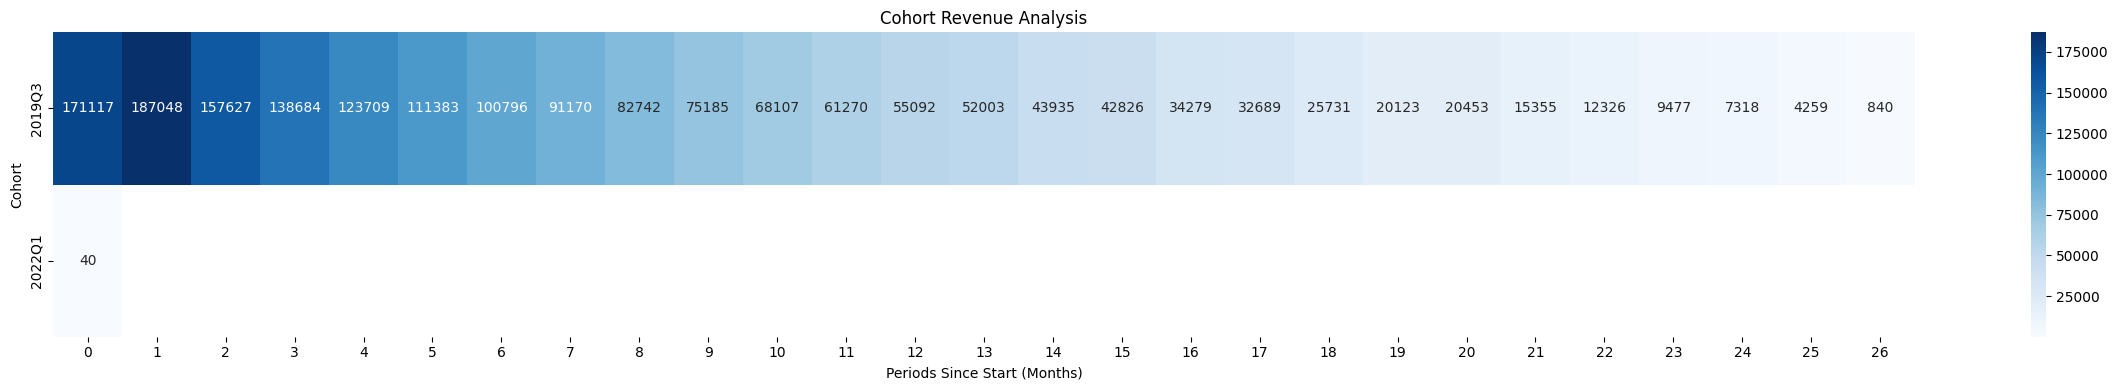

In [116]:
# Pivot table for heatmap
cohort_pivot = cohort_revenue.pivot_table(
    index='cohort',
    columns='periods_since_start',
    values='total_revenue'
)

plt.figure(figsize=(24, 4))

sns.heatmap(
    cohort_pivot,
    fmt='.0f',
    annot=True,
    annot_kws={'size': 10},
    cmap='Blues'
)

plt.title('Cohort Revenue Analysis')
plt.xlabel('Periods Since Start (Months)')
plt.ylabel('Cohort')
plt.tight_layout()
for label in ax.get_yticklabels():
    label.set_rotation(0)
plt.show()